# Задача №3. Методы машинного обучения, глубокого обучения и анализ аномалий

В данном ноутбуке выполняется задача сравнени ML- и DL-моделей прогнозирования временного ряда и выявление аномалий

In [1]:
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, IsolationForest
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error

ROOT = Path('..')
TRAIN_PATH = ROOT / 'data' / 'processed' / 'electricity_train.csv'
TEST_PATH = ROOT / 'data' / 'processed' / 'electricity_test.csv'
REPORTS = ROOT / 'reports'
FIGURES = REPORTS / 'figures'
REPORTS.mkdir(parents=True, exist_ok=True)
FIGURES.mkdir(parents=True, exist_ok=True)

DT = 'DateTime'
TARGET = 'Consumption'
H = 168

## 1. Загрузка данных

In [2]:
train_df = pd.read_csv(TRAIN_PATH, parse_dates=[DT]).sort_values(DT).reset_index(drop=True)
test_df = pd.read_csv(TEST_PATH, parse_dates=[DT]).sort_values(DT).reset_index(drop=True)

print(train_df.shape, test_df.shape)
train_df.head()

(36806, 16) (9202, 16)


,DateTime,Consumption,Production,Nuclear,Wind,Hydroelectric,Oil and Gas,Coal,Solar,Biomass,hour,dayofweek,month,is_weekend,year,split
0,2019-01-01 00:00:00,6352.0,6527.0,1395.0,79.0,1383.0,1896.0,1744.0,0.0,30.0,0,1,1,0,2019,train
1,2019-01-01 01:00:00,6116.0,5701.0,1393.0,96.0,1112.0,1429.0,1641.0,0.0,30.0,1,1,1,0,2019,train
2,2019-01-01 02:00:00,5873.0,5676.0,1393.0,142.0,1030.0,1465.0,1616.0,0.0,30.0,2,1,1,0,2019,train
3,2019-01-01 03:00:00,5682.0,5603.0,1397.0,191.0,972.0,1455.0,1558.0,0.0,30.0,3,1,1,0,2019,train
4,2019-01-01 04:00:00,5557.0,5454.0,1393.0,159.0,960.0,1454.0,1458.0,0.0,30.0,4,1,1,0,2019,train


## 2. Feature engineering для временного ряда

Для применения ML- и DL-моделей временной ряд преобразуется в задачу обучения с учителем. В качестве признаков используются лаги, скользящие статистики и календарные признаки.

Лаги `1`, `2`, `3` отражают краткосрочную динамику. Лаги `24`, `48` и `168` учитывают суточную и недельную сезонность. Скользящие средние и стандартные отклонения показывают локальный уровень и изменчивость ряда. Такой подход соответствует логике `mlforecast`, где временной ряд прогнозируется классическими ML-моделями по лаговым признакам.

In [3]:
LAGS = [1, 2, 3, 24, 48, 168]
ROLL_WINDOWS = [24, 168]

def make_supervised(df):
    data = df[[DT, TARGET]].copy().sort_values(DT)
    for lag in LAGS:
        data[f'lag_{lag}'] = data[TARGET].shift(lag)
    for window in ROLL_WINDOWS:
        data[f'rolling_mean_{window}'] = data[TARGET].shift(1).rolling(window).mean()
        data[f'rolling_std_{window}'] = data[TARGET].shift(1).rolling(window).std()
    data['hour'] = data[DT].dt.hour
    data['dayofweek'] = data[DT].dt.dayofweek
    data['month'] = data[DT].dt.month
    data['is_weekend'] = (data['dayofweek'] >= 5).astype(int)
    data['sin_hour'] = np.sin(2 * np.pi * data['hour'] / 24)
    data['cos_hour'] = np.cos(2 * np.pi * data['hour'] / 24)
    return data.dropna().reset_index(drop=True)

supervised_train = make_supervised(train_df)
feature_cols = [c for c in supervised_train.columns if c not in [DT, TARGET]]
X_train = supervised_train[feature_cols]
y_train = supervised_train[TARGET]

print(X_train.shape)
supervised_train.head()

(36638, 16)


,DateTime,Consumption,lag_1,lag_2,lag_3,lag_24,lag_48,lag_168,rolling_mean_24,rolling_std_24,rolling_mean_168,rolling_std_168,hour,dayofweek,month,is_weekend,sin_hour,cos_hour
0,2019-01-08 00:00:00,7106.0,7369.0,7859.0,8501.0,6512.0,6665.0,6352.0,7883.083333,1027.411899,7062.511905,1011.357361,0,1,1,0,0.000000,1.000000
1,2019-01-08 01:00:00,6951.0,7106.0,7369.0,7859.0,6270.0,6441.0,6116.0,7907.833333,999.728601,7067.000000,1009.857345,1,1,1,0,0.258819,0.965926
2,2019-01-08 02:00:00,6890.0,6951.0,7106.0,7369.0,6172.0,6297.0,5873.0,7936.208333,960.100220,7071.970238,1007.200082,2,1,1,0,0.500000,0.866025
3,2019-01-08 03:00:00,6839.0,6890.0,6951.0,7106.0,6228.0,6168.0,5682.0,7966.125000,912.756614,7078.023810,1002.998236,3,1,1,0,0.707107,0.707107
4,2019-01-08 04:00:00,6890.0,6839.0,6890.0,6951.0,6280.0,6260.0,5557.0,7991.583333,869.673698,7084.910714,997.311337,4,1,1,0,0.866025,0.500000


### Вывод по сформированным признакам

После преобразования временной ряд был представлен в виде обучающей таблицы для ML- и DL-моделей. Каждая строка соответствует одному моменту времени, а в качестве признаков используются прошлые значения ряда, скользящие статистики и календарные характеристики.

Лаговые признаки lag_1, lag_2, lag_3, lag_24, lag_48 и lag_168 позволяют моделям учитывать краткосрочную динамику, суточную и недельную сезонности. Признаки rolling_mean_24, rolling_std_24, rolling_mean_168 и rolling_std_168 описывают локальный уровень и изменчивость ряда за последние сутки и неделю.

Календарные признаки hour, dayofweek, month, is_weekend, sin_hour и cos_hour добавлены для учёта зависимости потребления от времени суток, дня недели и сезона. Циклические признаки sin_hour и cos_hour позволяют корректно представить час суток для модели.

После удаления строк с пропусками, возникшими из-за лагов и скользящих окон, в обучающей выборке осталось 36638 строк и 16 столбцов. 

## 3. MLForecast и ML-модели

mlforecast автоматизирует построение лаговых признаков и применение классических ML-моделей к временным рядам.

В практическом сравнении используются три ML-модели: Ridge, RandomForestRegressor и GradientBoostingRegressor. Ridge выбран как простая линейная модель с регуляризацией. RandomForest и GradientBoosting выбраны как нелинейные ансамблевые методы, способные учитывать сложные зависимости между лаговыми признаками и потреблением электроэнергии.

In [4]:
ml_models = {
    'MLForecast_Ridge_lags': make_pipeline(StandardScaler(), Ridge(alpha=1.0)),
    'MLForecast_RandomForest_lags': RandomForestRegressor(n_estimators=30, max_depth=10, random_state=42, n_jobs=-1, min_samples_leaf=5),
    'MLForecast_GradientBoosting_lags': GradientBoostingRegressor(n_estimators=60, learning_rate=0.06, max_depth=3, random_state=42),
}

try:
    import mlforecast
    print('mlforecast доступен:', mlforecast.__version__)
except Exception as e:
    print('mlforecast не найден, используется sklearn pipeline:', e)

mlforecast доступен: 1.0.31


## 4. NeuralForecast и нейросетевые модели

neuralforecast-специализированный фреймворк для нейросетевого прогнозирования временных рядов.

Для сравнения с ML-подходами в ноутбуке используются три нейросетевые модели типа MLP с разной архитектурой: малая, глубокая и широкая сеть. Такой набор позволяет проверить, даёт ли более гибкая нелинейная модель улучшение по сравнению с классическими ML-алгоритмами.

In [5]:
dl_models = {
    'Neural_MLP_small': make_pipeline(StandardScaler(), MLPRegressor(hidden_layer_sizes=(24,), max_iter=80, random_state=42, early_stopping=True)),
    'Neural_MLP_deep': make_pipeline(StandardScaler(), MLPRegressor(hidden_layer_sizes=(48, 24), max_iter=80, random_state=42, early_stopping=True)),
    'Neural_MLP_wide': make_pipeline(StandardScaler(), MLPRegressor(hidden_layer_sizes=(96,), max_iter=80, random_state=42, early_stopping=True)),
}

try:
    import neuralforecast
    print('neuralforecast доступен:', neuralforecast.__version__)
except Exception as e:
    print('neuralforecast не найден, используется sklearn MLP:', e)

neuralforecast доступен: 3.1.9


## 5. Обучение моделей и рекурсивный прогноз

Модели обучаются на лаговых признаках обучающей выборки. Прогноз строится на горизонте 168 часов. Для временного ряда используется рекурсивная схема: прогноз на следующий час добавляется в историю и затем используется для построения следующих лагов. Это позволяет не использовать фактические значения из тестовой выборки как признаки и избежать утечки данных.

In [6]:
def recursive_forecast(model, train_df, test_df, horizon=168):
    history = train_df[[DT, TARGET]].copy().sort_values(DT).reset_index(drop=True)
    preds = []
    for current_time in test_df[DT].iloc[:horizon]:
        row = {}
        values = history[TARGET]
        for lag in LAGS:
            row[f'lag_{lag}'] = values.iloc[-lag]
        for window in ROLL_WINDOWS:
            past = values.iloc[-window:]
            row[f'rolling_mean_{window}'] = past.mean()
            row[f'rolling_std_{window}'] = past.std()
        row['hour'] = current_time.hour
        row['dayofweek'] = current_time.dayofweek
        row['month'] = current_time.month
        row['is_weekend'] = int(current_time.dayofweek >= 5)
        row['sin_hour'] = np.sin(2 * np.pi * current_time.hour / 24)
        row['cos_hour'] = np.cos(2 * np.pi * current_time.hour / 24)
        pred = float(model.predict(pd.DataFrame([row])[feature_cols])[0])
        preds.append(pred)
        history = pd.concat([history, pd.DataFrame({DT: [current_time], TARGET: [pred]})], ignore_index=True)
    return np.array(preds)

all_models = {**ml_models, **dl_models}
for model in all_models.values():
    model.fit(X_train.tail(8000), y_train.tail(8000))

## 6. Сравнение качества ML/DL-моделей

Для оценки качества используются MAE, RMSE, sMAPE и MASE. Основная метрика — MAE, так как она показывает среднюю абсолютную ошибку в исходных единицах ряда. Горизонт 168 часов соответствует прогнозу на одну неделю вперёд.

In [7]:
def evaluate(y_true, y_pred, scale_mae):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    smape = np.mean(2 * np.abs(y_true - y_pred) / (np.abs(y_true) + np.abs(y_pred))) * 100
    mase = mae / scale_mae
    return mae, rmse, smape, mase, len(y_true)

y_true = test_df[TARGET].iloc[:H].values
indexed = pd.concat([train_df[[DT, TARGET]], test_df[[DT, TARGET]]]).set_index(DT)[TARGET]
seasonal_naive = [indexed.loc[t - pd.Timedelta(hours=24)] for t in test_df[DT].iloc[:H]]
scale_mae = mean_absolute_error(y_true, seasonal_naive)

forecast_df = pd.DataFrame({DT: test_df[DT].iloc[:H].values, 'y_true': y_true})
rows = []
for name, model in all_models.items():
    pred = recursive_forecast(model, train_df, test_df, horizon=H)
    forecast_df[name] = pred
    rows.append([name, *evaluate(y_true, pred, scale_mae)])

metrics_df = pd.DataFrame(rows, columns=['model', 'MAE', 'RMSE', 'sMAPE_%', 'MASE', 'n']).sort_values('MAE')
metrics_df.to_csv(REPORTS / 'ml_dl_model_comparison.csv', index=False)
forecast_df.to_csv(REPORTS / 'ml_dl_forecasts_test_h168.csv', index=False)
metrics_df

,model,MAE,RMSE,sMAPE_%,MASE,n
2,MLForecast_GradientBoosting_lags,278.608363,370.611758,4.435350,0.595863,168
1,MLForecast_RandomForest_lags,291.508952,358.929404,4.662262,0.623453,168
0,MLForecast_Ridge_lags,351.417992,442.210707,5.587663,0.751581,168
5,Neural_MLP_wide,2093.671595,2581.369188,41.563915,4.477758,168
3,Neural_MLP_small,3210.970787,3538.700624,70.959850,6.867337,168
4,Neural_MLP_deep,83579.423091,507704.119649,47.482794,178.752203,168


### Вывод по сравнению ML/DL-моделей

По результатам сравнения на тестовом горизонте 168 часов лучшее качество по основной метрике MAE показала модель MLForecast_GradientBoosting_lags: MAE = 278.61, RMSE = 370.61, sMAPE = 4.44%, MASE = 0.60. Это означает, что градиентный бустинг на лаговых, скользящих и календарных признаках лучше всего справился с прогнозированием потребления электроэнергии среди рассмотренных моделей машинного и глубокого обучения.

Второе место по MAE заняла модель MLForecast_RandomForest_lags: MAE = 291.51, RMSE = 358.93, sMAPE = 4.66%, MASE = 0.62. Несмотря на то, что её MAE немного выше, чем у градиентного бустинга, RMSE у неё ниже, и это означает, что RandomForest в среднем немного уступает GradientBoosting, но допускает меньшие крупные ошибки на отдельных точках прогноза.

Модель MLForecast_Ridge_lags показала третий результат: MAE = 351.42, RMSE = 442.21, sMAPE = 5.59%, MASE = 0.75. Ridge является линейной моделью, поэтому она хуже учитывает нелинейные зависимости во временном ряду, чем ансамблевые модели на деревьях. При этом значение MASE меньше 1, значит данная модель всё равно лучше сезонного наивного бейзлайна.

Нейросетевые MLP-модели в текущей настройке показали более слабые результаты. Лучшей среди них стала Neural_MLP_wide, но её MAE = 2093.67, sMAPE = 41.56%, MASE = 4.48, что существенно хуже результатов ML-моделей. Модели Neural_MLP_small и Neural_MLP_deep также дали высокие ошибки.

Таким образом, наиболее обоснованным выбором среди рассмотренных ML/DL-подходов является MLForecast_GradientBoosting_lags, так как она имеет минимальные MAE и sMAPE. Модель MLForecast_RandomForest_lags также можно рассматривать как сильную альтернативу, поскольку её качество близко к лучшему результату, а RMSE даже ниже. Нейросетевые модели нецелесообразно выбирать как итоговые, так как они требуют дополнительной настройки архитектуры, масштабирования признаков и параметров обучения.

## 7. Выявление аномалий во временном ряду

В этой части сравниваются три подхода к выявлению аномалий: IQR, rolling robust z-score и IsolationForest.


In [9]:
full_df = pd.concat([train_df, test_df]).sort_values(DT).reset_index(drop=True)
s = full_df[TARGET].astype(float)

q1, q3 = s.quantile([0.25, 0.75])
iqr = q3 - q1
full_df['anom_iqr'] = ((s < q1 - 1.5 * iqr) | (s > q3 + 1.5 * iqr)).astype(int)

rolling_median = s.rolling(168, center=True, min_periods=24).median()
mad = (s - rolling_median).abs().rolling(168, center=True, min_periods=24).median()
full_df['robust_z'] = 0.6745 * (s - rolling_median) / mad.replace(0, np.nan)
full_df['anom_rolling_robust_z'] = (full_df['robust_z'].abs() > 3.5).fillna(False).astype(int)

features_for_anomaly = pd.DataFrame({
    TARGET: s,
    'hour': full_df[DT].dt.hour,
    'dayofweek': full_df[DT].dt.dayofweek,
    'month': full_df[DT].dt.month,
    'is_weekend': (full_df[DT].dt.dayofweek >= 5).astype(int),
})
iso = IsolationForest(n_estimators=50, contamination=0.01, random_state=42)
full_df['anom_isolation_forest'] = (iso.fit_predict(features_for_anomaly) == -1).astype(int)

anomaly_summary = pd.DataFrame({
    'method': ['IQR', 'Rolling robust z-score', 'IsolationForest'],
    'n_anomalies': [full_df['anom_iqr'].sum(), full_df['anom_rolling_robust_z'].sum(), full_df['anom_isolation_forest'].sum()]
})
anomaly_summary['share_percent'] = anomaly_summary['n_anomalies'] / len(full_df) * 100

full_df[[DT, TARGET, 'robust_z', 'anom_iqr', 'anom_rolling_robust_z', 'anom_isolation_forest']].to_csv(REPORTS / 'anomaly_analysis_task3.csv', index=False)
anomaly_summary.to_csv(REPORTS / 'anomaly_methods_summary.csv', index=False)
anomaly_summary

,method,n_anomalies,share_percent
0,IQR,0,0.000000
1,Rolling robust z-score,3,0.006521
2,IsolationForest,458,0.995479


### Вывод по выявлению аномалий

В этом разделе были применены три метода выявления аномалий во временном ряду: IQR, Rolling robust z-score и IsolationForest. Они используют разные подходы, поэтому результаты отличаются.

Метод IQR не выявил аномалий: количество найденных аномальных точек равно 0. Это означает, что с точки зрения глобального распределения значений потребления в ряде нет грубых выбросов, сильно выходящих за межквартильные границы.

Метод Rolling robust z-score выявил 3 аномальные точки. Данный метод учитывает локальный контекст временного ряда, поэтому он может находить отдельные резкие отклонения относительно соседних значений, даже если они не являются выбросами по всему распределению.

Метод IsolationForest выявил 458 аномальных наблюдений, что составляет около 0.995% данных. Это связано с тем, что в модели заранее задан параметр contamination=0.01, то есть ожидаемая доля аномалий около 1%. В отличие от IQR и rolling z-score, IsolationForest учитывает не только само значение Consumption, но и дополнительные признаки: час, день недели, месяц и признак выходного дня.

Итоговый вывод: наиболее строгим методом оказался `IQR`, так как он не нашёл аномалий. Более чувствительным к локальным отклонениям оказался Rolling robust z-score, который выявил несколько редких резких изменений. IsolationForest нашёл больше аномалий, потому что использует многомерный ML-подход и заданную ожидаемую долю выбросов. Для дальнейшего анализа наиболее интерпретируемым вариантом можно считать Rolling robust z-score, так как он учитывает временной контекст и при этом не помечает слишком большую долю наблюдений как аномальные.

## 8. Визуализация результатов

Графики используются для визуальной проверки качества прогноза и анализа найденных аномалий. Первый график сравнивает фактический ряд и прогнозы лучших моделей. Второй показывает различия моделей по MAE. Третий отображает потенциальные аномалии, найденные rolling robust z-score.

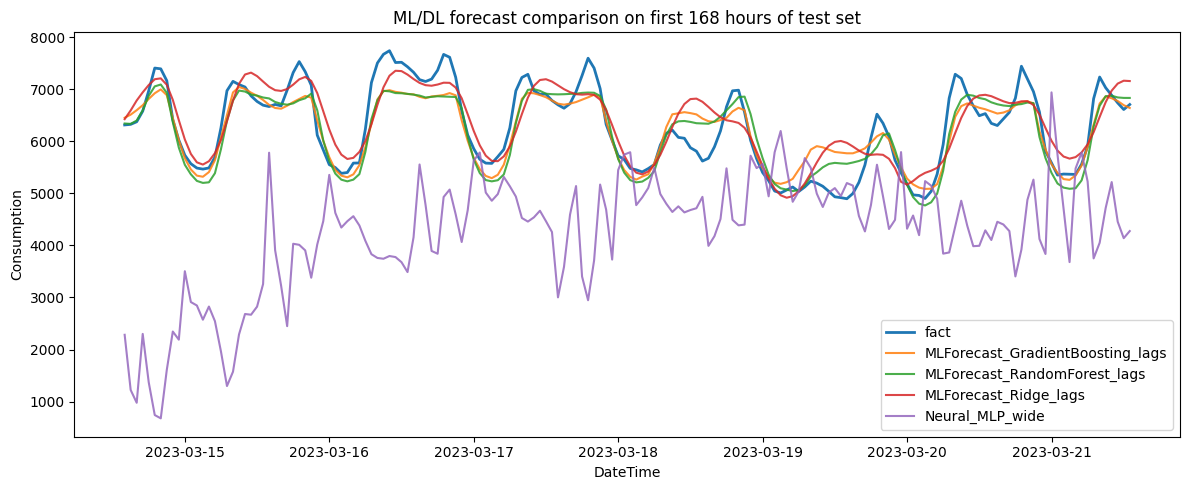

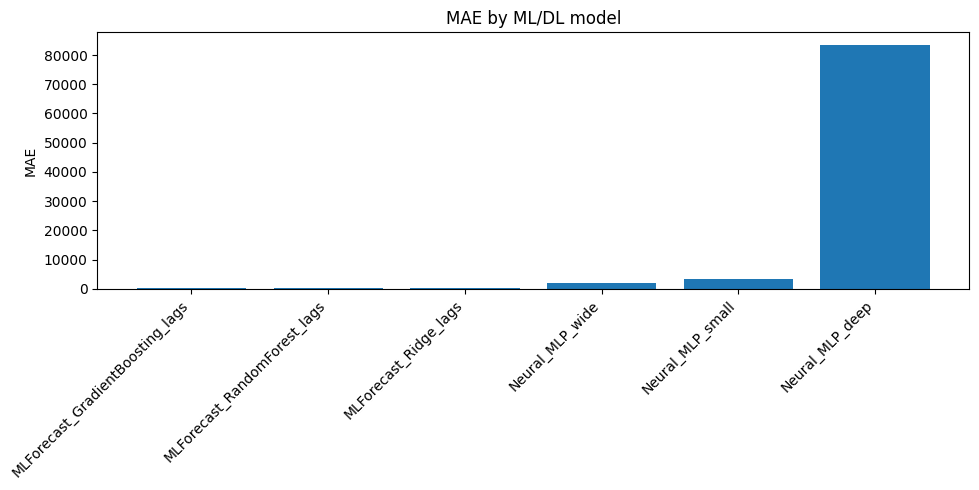

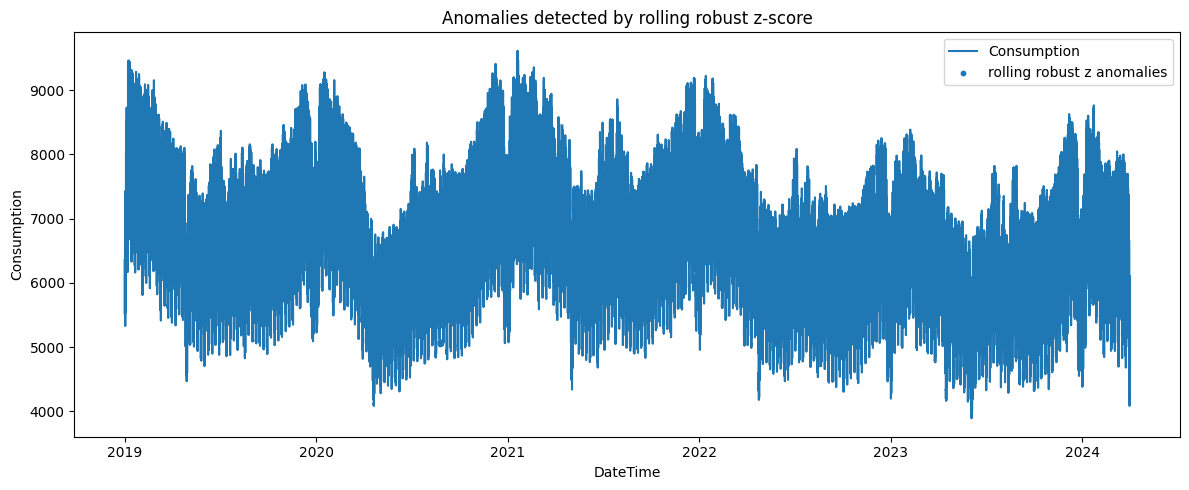

In [10]:
plt.figure(figsize=(12, 5))
plt.plot(forecast_df[DT], forecast_df['y_true'], label='fact', linewidth=2)
for name in metrics_df['model'].head(4):
    plt.plot(forecast_df[DT], forecast_df[name], label=name, alpha=0.85)
plt.title('ML/DL forecast comparison on first 168 hours of test set')
plt.xlabel('DateTime')
plt.ylabel(TARGET)
plt.legend()
plt.tight_layout()
plt.savefig(FIGURES / 'task3_forecast_comparison_h168.png', dpi=150)
plt.show()

plt.figure(figsize=(10, 5))
plt.bar(metrics_df['model'], metrics_df['MAE'])
plt.xticks(rotation=45, ha='right')
plt.ylabel('MAE')
plt.title('MAE by ML/DL model')
plt.tight_layout()
plt.savefig(FIGURES / 'task3_model_mae.png', dpi=150)
plt.show()

plt.figure(figsize=(12, 5))
mask = full_df['anom_rolling_robust_z'].astype(bool)
plt.plot(full_df[DT], full_df[TARGET], label='Consumption')
plt.scatter(full_df.loc[mask, DT], full_df.loc[mask, TARGET], s=10, label='rolling robust z anomalies')
plt.title('Anomalies detected by rolling robust z-score')
plt.xlabel('DateTime')
plt.ylabel(TARGET)
plt.legend()
plt.tight_layout()
plt.savefig(FIGURES / 'task3_anomalies_robust_z.png', dpi=150)
plt.show()

### Вывод по визуализации результатов

Первый график показывает сравнение фактических значений потребления электроэнергии с прогнозами лучших ML/DL-моделей на первых 168 часах тестовой выборки. Видно, что модели MLForecast_GradientBoosting_lags, MLForecast_RandomForest_lags и MLForecast_Ridge_lags в целом повторяют суточную форму временного ряда: дневные пики и ночные снижения. Это подтверждает, что лаговые, скользящие и календарные признаки позволяют ML-моделям учитывать основную сезонную структуру ряда.
При этом нейросетевая модель Neural_MLP_wide визуально заметно хуже совпадает с фактическим рядом: её прогнозы сильнее отклоняются от реальных значений и хуже повторяют уровень потребления. Это согласуется с таблицей метрик, где нейросетевые модели показали более высокие ошибки по сравнению с ML-моделями.

Второй график сравнивает модели по метрике MAE. Минимальное значение MAE имеет MLForecast_GradientBoosting_lags, следовательно, данная модель является лучшей по основной метрике качества. Близкий результат показывает MLForecast_RandomForest_lags, при этом MLForecast_Ridge_lags уступает ансамблевым моделям, так как является линейной и хуже описывает нелинейные зависимости в данных.

Третий график показывает потенциальные аномалии, найденные методом Rolling robust z-score. Таких точек немного, поэтому на общем графике временного ряда они почти не искажают основную структуру данных. Это согласуется с результатами таблицы аномалий: метод rolling robust z-score выявил только несколько редких локальных отклонений.

Тем самым, изуализация подтверждает численные результаты. Среди ML/DL-моделей  наиболее качественными оказались ML-модели на лаговых признаках, особенно MLForecast_GradientBoosting_lags и MLForecast_RandomForest_lags. Нейросетевые модели в текущей настройке требуют дополнительной доработки, а найденные аномалии не выглядят массовыми и не меняют общую сезонную структуру временного ряда.

## 9. Итоговые выводы

В рамках задачи №3 были рассмотрены методы машинного и глубокого обучения для анализа временного ряда потребления электроэнергии.

Для построения моделей временной ряд был преобразован в задачу обучения с учителем. В качестве признаков использовались лаги, скользящие статистики и календарные признаки. Такой подход позволяет ML- и DL-моделям учитывать краткосрочную динамику, суточную и недельную сезонность, а также зависимость потребления от времени суток и дня недели.

В работе были рассмотрены три ML-модели:

- MLForecast_Ridge_lags;
- MLForecast_RandomForest_lags;
- MLForecast_GradientBoosting_lags.

Также были рассмотрены три нейросетевые модели:

- Neural_MLP_small;
- Neural_MLP_deep;
- Neural_MLP_wide.

По результатам сравнения на тестовом горизонте 168 часов лучшее качество среди ML/DL-моделей показала модель MLForecast_GradientBoosting_lags: MAE = 278.61, RMSE = 370.61, sMAPE = 4.44%, MASE = 0.60. Близкий результат показала модель MLForecast_RandomForest_lags: MAE = 291.51, RMSE = 358.93, sMAPE = 4.66%, MASE = 0.62. Линейная модель MLForecast_Ridge_lags уступила ансамблевым моделям, но всё равно показала приемлемое качество.

Нейросетевые MLP-модели в текущей настройке показали заметно более слабые результаты по сравнению с ML-моделями. Это означает, что выбранные нейросетевые архитектуры требуют дополнительной настройки: подбора архитектуры, масштаба признаков, числа эпох, скорости обучения и других параметров, поэтому данные модели не выбираются как итоговые.

Для выявления аномалий были применены три метода:
- IQR;
- Rolling robust z-score;
- IsolationForest.

Метод IQR не выявил аномалий, что говорит об отсутствии грубых глобальных выбросов по распределению значений потребления. Метод Rolling robust z-score выявил 3 локальные аномалии, учитывая временной контекст и поведение ряда в окне. Метод IsolationForest выявил 458 аномальных наблюдений, что связано с заданным параметром contamination=0.01 и использованием нескольких признаков.

Наиболее интерпретируемым методом выявления аномалий для данного ряда можно считать Rolling robust z-score, так как он учитывает локальную структуру временного ряда и при этом не помечает слишком большую долю наблюдений как аномальные.

Итоговый выбор модели для прогнозирования — MLForecast_GradientBoosting_lags, так как она показала минимальные MAE и sMAPE среди рассмотренных ML/DL-подходов. В качестве альтернативы можно рассматривать MLForecast_RandomForest_lags, поскольку её качество близко к лучшему результату, а значение RMSE даже ниже, чем у градиентного бустинга.